Image loaded: 7360×4912 px


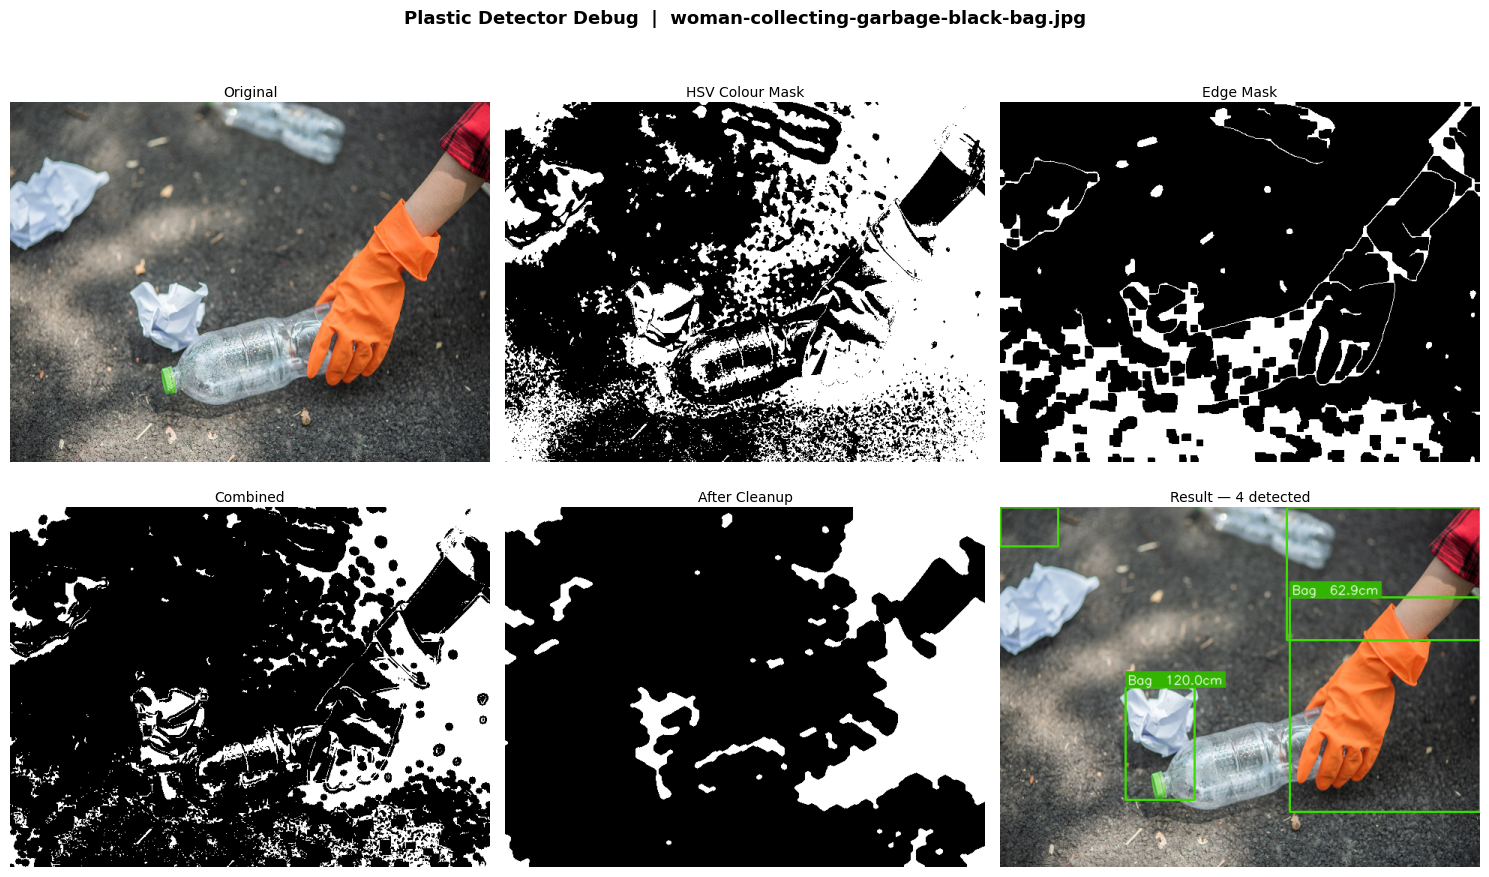


  Mask            |  Active px |      %
  ────────────────────────────────────
  color           |    139,120 |  45.3%
  edge            |     59,826 |  19.5%
  combined        |     76,025 |  24.7%
  cleaned         |     69,013 |  22.5%

  HSV range breakdown:
  black_bag    102,146px   33.3%  ███████████████████
  white         17,161px    5.6%  ███
  blue             311px    0.1%  
  red_lo        14,666px    4.8%  ██
  red_hi         3,592px    1.2%  
  yellow           305px    0.1%  
  green          1,972px    0.6%  

  ── Detections ──
  1. Bag         dist=120.0cm  bbox=(167,240,92×150)
  2. Bag         dist=62.9cm  bbox=(386,120,254×286)
  3. Plastic     dist=67.8cm  bbox=(382,0,258×177)
  4. Plastic     dist=230.8cm  bbox=(0,0,77×52)

✅  Saved → output_detections\result_woman-collecting-garbage-black-bag.jpg


In [1]:
# ================================================================
#  Plastic Waste Detector v3 — Simple & Working
#  Pure OpenCV + NumPy | Notebook / Script friendly
#  pip install opencv-python numpy matplotlib
# ================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, time
from pathlib import Path

# ================================================================
#  STEP 1 — SET YOUR IMAGE PATH HERE
# ================================================================
IMAGE_PATH  = r"C:\Users\User\Downloads\woman-collecting-garbage-black-bag.jpg"
OUTPUT_DIR  = "output_detections"

# ================================================================
#  STEP 2 — TUNING  (tweak these if detections are wrong)
# ================================================================

FOCAL_LENGTH_PX = 600          # calibrate: (px_height × dist_cm) / real_cm
REAL_HEIGHTS    = {"Bottle": 25.0, "Bag": 30.0, "Plastic": 20.0}

# Contour size gate
MIN_AREA   = 1_500             # raise to ignore small noise
MAX_AREA   = 200_000           # lower to ignore huge background blobs

# Shape gates  (lower = more permissive)
MIN_SOLIDITY    = 0.25
MIN_CIRCULARITY = 0.03

# ================================================================
#  STEP 3 — HSV COLOUR RANGES
#  These are TIGHT ranges — only real plastic colours, not sky/grass
#  Format: (name, lower_HSV, upper_HSV)
# ================================================================
HSV_RANGES = [
    # Dark / black plastic bags  (low value, any hue)
    ("black_bag",  np.array([  0,   0,   0]), np.array([179,  90,  80])),

    # White / translucent plastic bottles  (very low saturation, bright)
    ("white",      np.array([  0,   0, 200]), np.array([179,  40, 255])),

    # Blue plastic  (bottles, bags)
    ("blue",       np.array([100,  80,  50]), np.array([130, 255, 255])),

    # Red plastic  (bottles, wrappers) — two sub-ranges for wraparound
    ("red_lo",     np.array([  0, 100,  60]), np.array([ 10, 255, 255])),
    ("red_hi",     np.array([165, 100,  60]), np.array([179, 255, 255])),

    # Yellow / orange plastic  (juice bottles, wrappers)
    ("yellow",     np.array([ 15,  80,  80]), np.array([ 38, 255, 255])),

    # Green plastic  (bottles, bins)
    ("green",      np.array([ 40,  60,  40]), np.array([ 85, 255, 255])),
]

# ================================================================
#  CORE PIPELINE
# ================================================================

def get_hsv_mask(hsv):
    """Tight HSV union — only real plastic colours."""
    mask = np.zeros(hsv.shape[:2], np.uint8)
    for (_, lo, hi) in HSV_RANGES:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lo, hi))
    return mask


def get_edge_mask(gray):
    """Canny edges to catch transparent/shiny plastic outlines."""
    blur  = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    # Close small gaps in edges so contours form closed regions
    k     = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    return cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k, iterations=2)


def clean_mask(mask):
    """Remove noise and fill holes."""
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k, iterations=1)  # remove speckles
    m = cv2.morphologyEx(m,    cv2.MORPH_CLOSE, k, iterations=3)  # fill holes
    return m


def classify_and_filter(contours):
    """
    Filter contours by area + shape.
    Returns list of (contour, label, distance_cm).
    """
    results = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (MIN_AREA <= area <= MAX_AREA):
            continue

        peri      = cv2.arcLength(cnt, True)
        hull_area = cv2.contourArea(cv2.convexHull(cnt))
        x, y, w, h = cv2.boundingRect(cnt)

        circ    = (4 * np.pi * area / peri**2) if peri > 0 else 0
        solid   = (area / hull_area)            if hull_area > 0 else 0
        aspect  = min(w, h) / max(w, h)         if max(w, h) > 0 else 0

        if solid < MIN_SOLIDITY or circ < MIN_CIRCULARITY:
            continue

        # Classify by shape
        if h > w * 1.5 and solid > 0.45:
            label = "Bottle"
        elif circ > 0.50 and solid > 0.60:
            label = "Bottle"
        elif aspect > 0.7 or solid < 0.60:
            label = "Bag"
        else:
            label = "Plastic"

        dist = round((REAL_HEIGHTS[label] * FOCAL_LENGTH_PX) / h, 1) if h > 0 else 0
        results.append((cnt, label, dist, (x, y, w, h)))

    return results


def detect(image_bgr):
    """
    Main detection function.
    Returns (annotated_image, list_of_detections).
    """
    img = cv2.resize(image_bgr, (640, 480), interpolation=cv2.INTER_AREA)

    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Build masks
    color_mask = get_hsv_mask(hsv)
    edge_mask  = get_edge_mask(gray)

    # Combine: pixel must appear in BOTH color AND edge regions, OR in color alone
    # (this cuts down on pure-edge false positives like grass blades)
    combined = cv2.bitwise_or(
        cv2.bitwise_and(color_mask, edge_mask),   # colour + edge overlap
        cv2.erode(color_mask,                     # or strong colour blob
                  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)),
                  iterations=1)
    )

    cleaned = clean_mask(combined)

    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    detections = classify_and_filter(contours)

    # Draw results
    out = img.copy()
    for (cnt, label, dist, (x, y, w, h)) in detections:
        cv2.rectangle(out, (x, y), (x+w, y+h), (0, 220, 60), 2)
        text  = f"{label}  {dist}cm"
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(out, (x, y-th-8), (x+tw+6, y), (0, 180, 50), -1)
        cv2.putText(out, text, (x+3, y-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1,
                    cv2.LINE_AA)

    return out, detections, {"color": color_mask, "edge": edge_mask,
                             "combined": combined, "cleaned": cleaned}


# ================================================================
#  DEBUG VISUALISER  — shows every stage clearly
# ================================================================

def show_debug(image_bgr, path=""):
    """Show 6-panel debug view."""
    annotated, dets, masks = detect(image_bgr)

    img_resized = cv2.resize(image_bgr, (640, 480))
    panels = [
        (cv2.cvtColor(img_resized,  cv2.COLOR_BGR2RGB), "Original"),
        (masks["color"],                                 "HSV Colour Mask"),
        (masks["edge"],                                  "Edge Mask"),
        (masks["combined"],                              "Combined"),
        (masks["cleaned"],                               "After Cleanup"),
        (cv2.cvtColor(annotated,    cv2.COLOR_BGR2RGB), f"Result — {len(dets)} detected"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f"Plastic Detector Debug  |  {Path(path).name}",
                 fontsize=13, fontweight="bold", y=1.01)

    for ax, (img, title) in zip(axes.flat, panels):
        cmap = None if len(img.shape) == 3 else "gray"
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=10, pad=4)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # Stats
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    total = 640 * 480
    print(f"\n  {'Mask':<15} | {'Active px':>10} | {'%':>6}")
    print(f"  {'─'*36}")
    for name, m in masks.items():
        wp = int(np.sum(m > 0))
        print(f"  {name:<15} | {wp:>10,} | {wp/total*100:>5.1f}%")

    print(f"\n  HSV range breakdown:")
    for (name, lo, hi) in HSV_RANGES:
        m  = cv2.inRange(hsv, lo, hi)
        wp = int(np.sum(m > 0))
        bar = "█" * min(int(wp/total*60), 30)
        print(f"  {name:<12} {wp:>7,}px  {wp/total*100:>5.1f}%  {bar}")

    print(f"\n  ── Detections ──")
    if dets:
        for i, (_, label, dist, (x,y,w,h)) in enumerate(dets, 1):
            print(f"  {i}. {label:<10}  dist={dist}cm  bbox=({x},{y},{w}×{h})")
    else:
        print("  None found — see suggestions below.")
        _print_suggestions(masks, total)

    return annotated, dets


def _print_suggestions(masks, total):
    color_pct = np.sum(masks["color"] > 0) / total * 100
    clean_pct = np.sum(masks["cleaned"] > 0) / total * 100

    print("\n  ── Diagnosis & Suggestions ──")
    if color_pct > 50:
        print(f"  ⚠  HSV mask is {color_pct:.0f}% active — too broad!")
        print("     → The HSV ranges are matching background (sky/grass/skin).")
        print("     → Use sample_pixel() below to find your plastic's exact HSV,")
        print("       then REPLACE the matching range with tighter lo/hi values.")
    if clean_pct > 80:
        print(f"  ⚠  Cleaned mask fills {clean_pct:.0f}% of frame → only 1 giant blob.")
        print("     → Fix the HSV mask first, then retest.")
    if color_pct < 5:
        print(f"  ⚠  HSV mask is only {color_pct:.0f}% active — plastic colour not matched.")
        print("     → Use sample_pixel() to find the correct HSV range.")
    print("  → Raise MIN_AREA if small noise blobs are detected as plastic.")
    print("  → Lower MIN_SOLIDITY (try 0.10) for crumpled bags.\n")


# ================================================================
#  PIXEL HSV SAMPLER — find the right HSV for your plastic
# ================================================================

def sample_pixel(path, x, y, radius=12):
    """
    Print the HSV values around pixel (x, y) so you can design
    a tight HSV range for that exact plastic colour.

    Usage:
        sample_pixel("image.jpg", x=310, y=200)
    """
    img  = cv2.resize(cv2.imread(path), (640, 480))
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    x1, x2 = max(0, x-radius), min(640, x+radius)
    y1, y2 = max(0, y-radius), min(480, y+radius)
    patch  = hsv[y1:y2, x1:x2].reshape(-1, 3)

    lo = patch.min(axis=0)
    hi = patch.max(axis=0)
    med = np.median(patch, axis=0).astype(int)

    pad = 15
    sug_lo = np.clip(lo - pad, [0,0,0],   [179,255,255])
    sug_hi = np.clip(hi + pad, [0,0,0],   [179,255,255])

    print(f"\n  Pixel ({x},{y}) HSV:")
    print(f"  Median : H={med[0]}  S={med[1]}  V={med[2]}")
    print(f"  Range  : H={lo[0]}-{hi[0]}  S={lo[1]}-{hi[1]}  V={lo[2]}-{hi[2]}")
    print(f"\n  Paste this into HSV_RANGES:")
    print(f'  ("my_plastic", np.array({sug_lo.tolist()}), np.array({sug_hi.tolist()})),')

    # Show image with sample region marked
    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(vis)
    import matplotlib.patches as mp
    ax.add_patch(mp.Rectangle((x1,y1), x2-x1, y2-y1,
                               lw=2, edgecolor="red", facecolor="none"))
    ax.set_title(f"Sample region  H={med[0]} S={med[1]} V={med[2]}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# ================================================================
#  BATCH MODE
# ================================================================

def run_batch(folder):
    """Process all images in a folder and print a summary table."""
    exts  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    paths = sorted(p for p in Path(folder).iterdir()
                   if p.suffix.lower() in exts)

    if not paths:
        print(f"No images found in: {folder}"); return

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"\n  {'Image':<30} | {'Det':>4} | {'ms':>7} | {'Avg dist':>9}")
    print(f"  {'─'*58}")

    for p in paths:
        img = cv2.imread(str(p))
        if img is None: continue
        t0 = time.perf_counter()
        out, dets, _ = detect(img)
        ms = (time.perf_counter() - t0) * 1000
        avg_d = sum(d[2] for d in dets) / len(dets) if dets else 0
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"det_{p.name}"), out)
        print(f"  {p.name:<30} | {len(dets):>4} | {ms:>7.1f} | {avg_d:>8.1f}")


# ================================================================
#  RUN
# ================================================================

if __name__ == "__main__":
    if not os.path.isfile(IMAGE_PATH):
        print(f"\n❌  File not found: {IMAGE_PATH}")
        print("   Update IMAGE_PATH at the top of the script.\n")
    else:
        img = cv2.imread(IMAGE_PATH)
        print(f"Image loaded: {img.shape[1]}×{img.shape[0]} px")

        annotated, dets = show_debug(img, IMAGE_PATH)[:2]

        os.makedirs(OUTPUT_DIR, exist_ok=True)
        out_path = os.path.join(OUTPUT_DIR, "result_" + Path(IMAGE_PATH).name)
        cv2.imwrite(out_path, annotated)
        print(f"\n✅  Saved → {out_path}")

        # ── Uncomment to sample a pixel from your image ──────────
        # sample_pixel(IMAGE_PATH, x=320, y=240)

        # ── Uncomment for batch mode ─────────────────────────────
        # run_batch("test_images/")



Detected 30 plastic item(s) in 0.82s

  [1] PET Bottle (Blue)
       Distance : 27.2 cm
       Size     : 6.5 x 3.1 cm
       Area     : 9.9 cm2
  [2] PET Bottle (Blue)
       Distance : 18.1 cm
       Size     : 6.5 x 2.7 cm
       Area     : 6.3 cm2
  [3] PET Bottle (Blue)
       Distance : 36.4 cm
       Size     : 6.5 x 6.6 cm
       Area     : 25.7 cm2
  [4] PET Bottle (Blue)
       Distance : 30.5 cm
       Size     : 6.5 x 3.6 cm
       Area     : 13.8 cm2
  [5] HDPE / White Plastic
       Distance : 119.7 cm
       Size     : 6.5 x 5.5 cm
       Area     : 18.3 cm2
  [6] HDPE / White Plastic
       Distance : 68.9 cm
       Size     : 6.5 x 5.7 cm
       Area     : 21.0 cm2
  [7] HDPE / White Plastic
       Distance : 87.5 cm
       Size     : 6.5 x 4.4 cm
       Area     : 20.3 cm2
  [8] HDPE / White Plastic
       Distance : 77.1 cm
       Size     : 6.5 x 4.6 cm
       Area     : 20.0 cm2
  [9] PVC / Dark Plastic
       Distance : 151.7 cm
       Size     : 6.5 x 9.7 cm
   

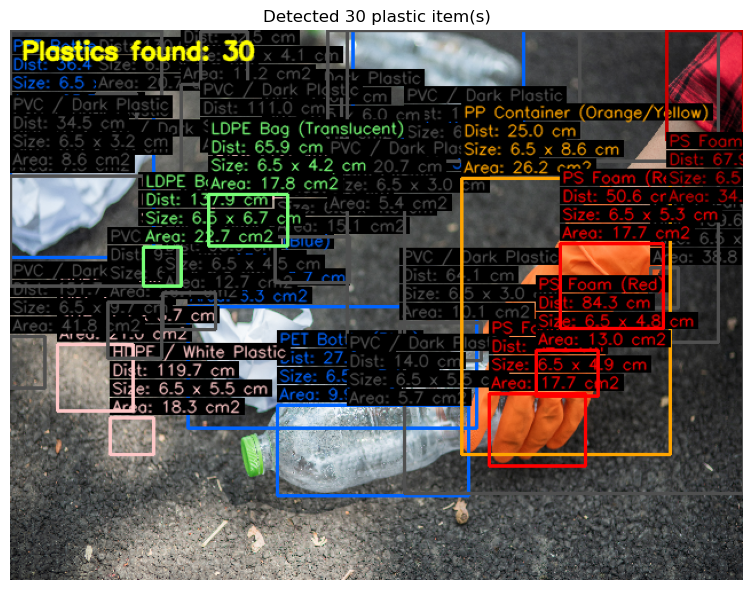


Saved -> output_detected.jpg


In [3]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# CAMERA CALIBRATION CONSTANTS
# To calibrate: place an object of known width (e.g. 6.5 cm bottle)
# at a known distance, measure its pixel width, then:
#   FOCAL_LENGTH = (pixel_width * known_distance_cm) / known_width_cm
# ─────────────────────────────────────────────────────────────────
FOCAL_LENGTH_PX  = 700.0   # Replace with your calibrated value
KNOWN_WIDTH_CM   = 6.5     # Real width of a typical plastic bottle (cm)
MIN_CONTOUR_AREA = 500     # Ignore blobs smaller than this (px^2)


# ─────────────────────────────────────────────────────────────────
# HSV COLOR RANGES FOR EACH PLASTIC TYPE
# Format: (lower_hsv, upper_hsv, label, box_color_BGR)
# Tip: Run hsv_calibrator() at the bottom to tune these for your
#      specific lighting environment.
# ─────────────────────────────────────────────────────────────────
PLASTIC_TYPES = [
    (np.array([100,  50,  50]), np.array([130, 255, 255]), "PET Bottle (Blue)",           (255, 100,   0)),
    (np.array([  0,   0, 200]), np.array([180,  30, 255]), "HDPE / White Plastic",        (200, 200, 255)),
    (np.array([  0,   0,   0]), np.array([180,  60,  80]), "PVC / Dark Plastic",          ( 80,  80,  80)),
    (np.array([ 40,   5, 180]), np.array([ 90,  60, 255]), "LDPE Bag (Translucent)",      (120, 255, 120)),
    (np.array([ 10,  80,  80]), np.array([ 35, 255, 255]), "PP Container (Orange/Yellow)",(  0, 165, 255)),
    (np.array([  0,  80,  80]), np.array([ 10, 255, 255]), "PS Foam (Red)",               (  0,   0, 255)),
    (np.array([170,  80,  80]), np.array([180, 255, 255]), "PS Foam (Red wrap)",          (  0,   0, 200)),
]


# ─────────────────────────────────────────────────────────────────
# STEP 1: LIGHTING NORMALIZATION
# Makes HSV detection stable across indoor/outdoor/shadows.
# ─────────────────────────────────────────────────────────────────
def normalize_lighting(img):
    # Gray-world white balance: removes warm/cool color casts
    img_f = img.astype(np.float32)
    mb, mg, mr = np.mean(img_f[:,:,0]), np.mean(img_f[:,:,1]), np.mean(img_f[:,:,2])
    gm = (mb + mg + mr) / 3.0
    img_f[:,:,0] *= gm / (mb + 1e-6)
    img_f[:,:,1] *= gm / (mg + 1e-6)
    img_f[:,:,2] *= gm / (mr + 1e-6)
    img = np.clip(img_f, 0, 255).astype(np.uint8)

    # CLAHE on LAB L-channel: fixes uneven brightness / shadows
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    return img


# ─────────────────────────────────────────────────────────────────
# STEP 2: DISTANCE ESTIMATION  (pinhole camera model)
#   distance_cm = (real_width_cm * focal_length_px) / pixel_width
# ─────────────────────────────────────────────────────────────────
def estimate_distance(pixel_width):
    if pixel_width <= 0:
        return None
    return (KNOWN_WIDTH_CM * FOCAL_LENGTH_PX) / pixel_width


# ─────────────────────────────────────────────────────────────────
# STEP 3: SIZE ESTIMATION
#   pixels_per_cm = focal_length / distance_cm
#   real_area_cm2 = pixel_area / pixels_per_cm^2
# ─────────────────────────────────────────────────────────────────
def estimate_size(pixel_area, pixel_width, pixel_height, distance_cm):
    if distance_cm is None or distance_cm <= 0:
        return None, None, None
    ppcm     = FOCAL_LENGTH_PX / distance_cm
    real_w   = round(pixel_width  / ppcm, 1)
    real_h   = round(pixel_height / ppcm, 1)
    real_area = round(pixel_area  / (ppcm ** 2), 1)
    return real_area, real_w, real_h


# ─────────────────────────────────────────────────────────────────
# MAIN DETECTION FUNCTION  (single image)
# ─────────────────────────────────────────────────────────────────
def detect_plastic(image_path):
    # Load and resize
    img = cv2.imread(image_path)
    if img is None:
        print("Error loading image:", image_path)
        return None, []
    img = cv2.resize(img, (640, 480))

    # Normalize lighting then blur
    img_norm = normalize_lighting(img)
    img_blur = cv2.GaussianBlur(img_norm, (5, 5), 0)
    hsv      = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)

    output   = img.copy()
    detected = []
    kernel   = np.ones((5, 5), np.uint8)

    for (lower, upper, label, color) in PLASTIC_TYPES:
        # Build and clean mask
        mask = cv2.inRange(hsv, lower, upper)
        mask = cv2.erode (mask, kernel, iterations=1)
        mask = cv2.dilate(mask, kernel, iterations=2)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < MIN_CONTOUR_AREA:
                continue

            # Circularity filter: keeps bottles and bags, rejects thin lines
            perimeter   = cv2.arcLength(cnt, True)
            circularity = (4 * np.pi * area / perimeter ** 2) if perimeter > 0 else 0
            if circularity < 0.2 and area < 3000:
                continue

            x, y, w, h   = cv2.boundingRect(cnt)
            distance_cm  = estimate_distance(w)
            real_area, real_w, real_h = estimate_size(area, w, h, distance_cm)

            detected.append({
                "label":       label,
                "bbox":        (x, y, w, h),
                "distance_cm": distance_cm,
                "real_w":      real_w,
                "real_h":      real_h,
                "real_area":   real_area,
            })

            # Draw bounding box
            cv2.rectangle(output, (x, y), (x + w, y + h), color, 2)

            # Build annotation lines
            dist_txt = f"Dist: {distance_cm:.1f} cm" if distance_cm else "Dist: N/A"
            size_txt = f"Size: {real_w} x {real_h} cm" if real_w    else "Size: N/A"
            area_txt = f"Area: {real_area} cm2"         if real_area else "Area: N/A"

            for i, txt in enumerate([label, dist_txt, size_txt, area_txt]):
                ty = y - 5 - (3 - i) * 16
                if ty < 10:
                    ty = y + h + 5 + i * 16
                (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
                cv2.rectangle(output, (x, ty - th - 2), (x + tw + 4, ty + 2), (0, 0, 0), -1)
                cv2.putText(output, txt, (x + 2, ty),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    cv2.putText(output, f"Plastics found: {len(detected)}", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv2.LINE_AA)

    return output, detected


# ─────────────────────────────────────────────────────────────────
# LIVE WEBCAM DETECTION
# ─────────────────────────────────────────────────────────────────
def detect_plastic_live(camera_index=0):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Error: cannot open camera", camera_index)
        return

    print("Live detection running. Press Q to quit.")
    kernel    = np.ones((5, 5), np.uint8)
    fps_start = time.time()
    frames    = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame  = cv2.resize(frame, (640, 480))
        frames += 1

        norm  = normalize_lighting(frame)
        blur  = cv2.GaussianBlur(norm, (5, 5), 0)
        hsv   = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
        output   = frame.copy()
        n_detect = 0

        for (lower, upper, label, color) in PLASTIC_TYPES:
            mask = cv2.inRange(hsv, lower, upper)
            mask = cv2.erode (mask, kernel, iterations=1)
            mask = cv2.dilate(mask, kernel, iterations=2)

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if area < MIN_CONTOUR_AREA:
                    continue
                perimeter   = cv2.arcLength(cnt, True)
                circularity = (4 * np.pi * area / perimeter ** 2) if perimeter > 0 else 0
                if circularity < 0.2 and area < 3000:
                    continue

                x, y, w, h  = cv2.boundingRect(cnt)
                distance_cm = estimate_distance(w)
                _, real_w, real_h = estimate_size(area, w, h, distance_cm)
                n_detect += 1

                cv2.rectangle(output, (x, y), (x + w, y + h), color, 2)

                dist_txt = f"{distance_cm:.1f}cm" if distance_cm else "?"
                size_txt = f"{real_w}x{real_h}cm" if real_w      else "?"
                info     = f"{label} | {dist_txt} | {size_txt}"

                (tw, th), _ = cv2.getTextSize(info, cv2.FONT_HERSHEY_SIMPLEX, 0.42, 1)
                ty = y - 6 if y - 6 > th else y + h + th + 4
                cv2.rectangle(output, (x, ty - th - 2), (x + tw + 4, ty + 2), (0, 0, 0), -1)
                cv2.putText(output, info, (x + 2, ty),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)

        fps = frames / (time.time() - fps_start + 1e-6)
        cv2.putText(output, f"FPS: {fps:.1f}  |  Detected: {n_detect}", (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(output, "Q = quit", (10, 460),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (150, 150, 150), 1)

        cv2.imshow("Plastic Waste Detector", output)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


# ─────────────────────────────────────────────────────────────────
# HSV CALIBRATOR
# Run this FIRST to find the right HSV ranges for your lighting.
# Adjust the 6 sliders until only your plastic shows white.
# The terminal prints the range to paste into PLASTIC_TYPES above.
# ─────────────────────────────────────────────────────────────────
def hsv_calibrator(camera_index=0):
    cap = cv2.VideoCapture(camera_index)
    win = "HSV Calibrator  |  Q = quit & print range"
    cv2.namedWindow(win)
    cv2.createTrackbar("H min", win,   0, 179, lambda x: None)
    cv2.createTrackbar("H max", win, 179, 179, lambda x: None)
    cv2.createTrackbar("S min", win,   0, 255, lambda x: None)
    cv2.createTrackbar("S max", win, 255, 255, lambda x: None)
    cv2.createTrackbar("V min", win,   0, 255, lambda x: None)
    cv2.createTrackbar("V max", win, 255, 255, lambda x: None)
    print("Adjust sliders to isolate your plastic. Press Q when done.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (640, 480))
        hsv   = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        lower = np.array([cv2.getTrackbarPos("H min", win),
                          cv2.getTrackbarPos("S min", win),
                          cv2.getTrackbarPos("V min", win)])
        upper = np.array([cv2.getTrackbarPos("H max", win),
                          cv2.getTrackbarPos("S max", win),
                          cv2.getTrackbarPos("V max", win)])

        mask   = cv2.inRange(hsv, lower, upper)
        result = cv2.bitwise_and(frame, frame, mask=mask)
        panel  = np.hstack([frame, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), result])
        cv2.putText(panel, f"H:{lower[0]}-{upper[0]}  S:{lower[1]}-{upper[1]}  V:{lower[2]}-{upper[2]}",
                    (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 1)
        cv2.imshow(win, panel)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            print(f"\nAdd this to PLASTIC_TYPES:")
            print(f"  (np.array([{lower[0]}, {lower[1]}, {lower[2]}]),")
            print(f"   np.array([{upper[0]}, {upper[1]}, {upper[2]}]),")
            print(f'   "Your Label Here", (B, G, R)),')
            break

    cap.release()
    cv2.destroyAllWindows()


# ─────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # ── Change this to your image path ───────────────────────────
    IMAGE_PATH = r"C:\Users\User\Downloads\woman-collecting-garbage-black-bag.jpg"

    # ── To use live webcam instead, comment out the image block
    #    below and uncomment this line:
    # detect_plastic_live(camera_index=0)

    # ── To find HSV ranges for a new plastic, uncomment this:
    # hsv_calibrator(camera_index=0)

    # ── Image detection ───────────────────────────────────────────
    start = time.time()
    result_img, detections = detect_plastic(IMAGE_PATH)

    if result_img is not None:
        print(f"\nDetected {len(detections)} plastic item(s) in {time.time() - start:.2f}s\n")
        for i, det in enumerate(detections):
            dist = f"{det['distance_cm']:.1f} cm" if det['distance_cm'] else "N/A"
            size = f"{det['real_w']} x {det['real_h']} cm" if det['real_w'] else "N/A"
            area = f"{det['real_area']} cm2" if det['real_area'] else "N/A"
            print(f"  [{i+1}] {det['label']}")
            print(f"       Distance : {dist}")
            print(f"       Size     : {size}")
            print(f"       Area     : {area}")

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected {len(detections)} plastic item(s)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        cv2.imwrite("output_detected.jpg", result_img)
        print("\nSaved -> output_detected.jpg")